## Multiple Linear Regression

### 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

### 2. Import dataset

In [3]:
X=pd.read_csv('LR_X.csv')
Y=pd.read_csv('LR_Y.csv')

### 3. Check shape of dataset

In [4]:
X.shape

(1000, 3)

In [5]:
Y.shape

(1000, 1)

### 4. Check the data in X and Y

In [6]:
X.head()

,X1,X2,X3
0,0.26,0.08,0.28
1,0.26,0.52,0.01
2,0.85,0.60,0.14
3,0.94,0.22,0.48
4,0.53,0.05,0.76


In [7]:
Y.head()

,Y
0,1.472
1,1.802
2,1.548
3,1.390
4,2.141


### 5. Check range of the data

In [8]:
X.describe()

,X1,X2,X3
count,1000.000000,1000.000000,1000.000000
mean,0.493360,0.501480,0.493320
std,0.287477,0.287708,0.285183
min,0.000000,0.000000,0.000000
25%,0.250000,0.270000,0.250000
50%,0.480000,0.495000,0.490000
75%,0.740000,0.750000,0.730000
max,1.000000,1.000000,1.000000


All attribute ranges from 0 to 1. Normalization is not required

### 6. Append a column with the independent variable X
take a matrix of one only for cancatenation to X

In [9]:
ones=np.ones((1000,1))

In [10]:
ones.shape

(1000, 1)

In [11]:
ones[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [12]:
new_X=np.concatenate((ones,X),axis=1)

In [13]:
new_X

array([[1.  , 0.26, 0.08, 0.28],
       [1.  , 0.26, 0.52, 0.01],
       [1.  , 0.85, 0.6 , 0.14],
       ...,
       [1.  , 0.88, 0.06, 0.33],
       [1.  , 0.28, 0.4 , 0.41],
       [1.  , 0.94, 0.48, 0.45]], shape=(1000, 4))

In [14]:
new_X.shape

(1000, 4)

In [15]:
res1=np.linalg.inv(np.dot(np.transpose(new_X),new_X))

In [16]:
res1.shape

(4, 4)

In [17]:
res2=np.dot(np.transpose(new_X),Y)
res2.shape

(4, 1)

In [18]:
beta=np.dot(res1,res2)
print(beta)

[[ 1. ]
 [-1.2]
 [ 2.1]
 [ 2.2]]


### 7. The equation of the linear regression is Y=1.0-1.2x1+2.1x2+2.2*x2

## Gradient Descent

In [22]:
data=pd.read_table('P176.txt')

In [23]:
x=data['X']
y=data['Y']

In [24]:
x

0      294
1      247
2      267
3      358
4      423
5      311
6      450
7      534
8      438
9      697
10     688
11     630
12     709
13     627
14     615
15     999
16    1022
17    1015
18     700
19     850
20     980
21    1025
22    1021
23    1200
24    1250
25    1500
26    1650
Name: X, dtype: int64

### 1. Normalize data


In [25]:
x1=(x-np.mean(x))/np.std(x)
y1=(y-np.mean(y))/np.std(y)

In [26]:
def grad_beta0(beta0,beta1,x1,y1):
    n=len(x1)
    res=0
    for i in range(n):
        res+=(y1[i]-beta0-beta1*x1[i])
    grad_b0=-2/float(n)*res
    #print(grad_b0)
    return grad_b0

In [27]:
def grad_beta1(beta0,beta1,x1,y1):
    n=len(x1)
    res=0
    for i in range(n):
        res+=x1[i]*(y1[i]-beta0-beta1*x1[i])
    grad_b1=-2/float(n)*res
    #print(grad_b1)
    return grad_b1

In [28]:
def gradient_descent(x,y):
    beta0=0
    beta1=0
    lr=0.1
    epochs=1
    while epochs<=100:
        up_b0=grad_beta0(beta0,beta1,x1,y1)
        up_b1=grad_beta1(beta0,beta1,x1,y1)
        beta0=beta0-lr*up_b0
        beta1=beta1-lr*up_b1
        y_hat=beta0+beta1*x
        plt.plot(x,y_hat)
        epochs+=1
    return beta0,beta1

-5.468876380560958e-17 0.8808360812820623


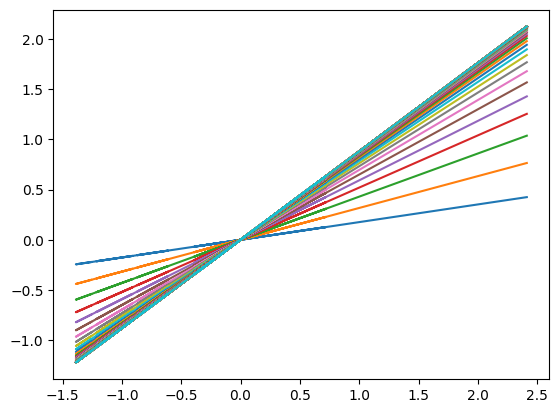

In [29]:
b0,b1=gradient_descent(x1,y1)
print(b0,b1)

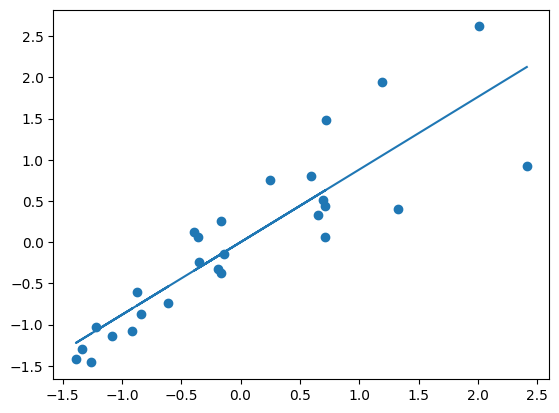

In [30]:
plt.scatter(x1,y1)
#x2=np.linspace(-3,3,500)
y2=b0+b1*x1
plt.plot(x1,y2,'-')
plt.show()

## Use array operations

In [31]:
def gradient_descent1(x,y):
    beta0=0
    beta1=0
    lr=0.01
    epochs=1
    n=float(len(x))
    while epochs<=1000:
        y_hat=beta0+beta1*x
        up_b0=-(2/n)*np.sum(y-y_hat)
        up_b1=-(2/n)*np.sum(x*(y-y_hat))
        beta0=beta0-lr*up_b0
        beta1=beta1-lr*up_b1
        epochs+=1
    return beta0,beta1

In [32]:
b0,b1=gradient_descent1(x1,y1)
print(b0,b1)

-5.5017718775868785e-17 0.8808360799790734


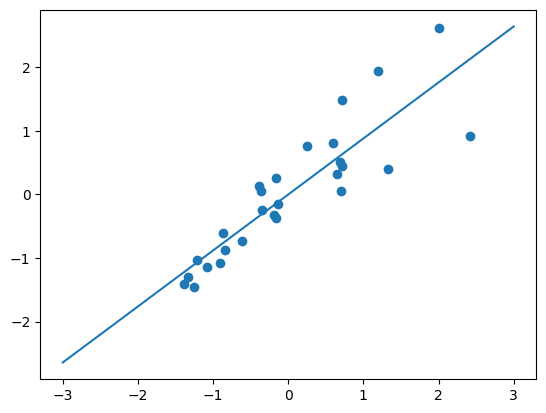

In [33]:
plt.scatter(x1,y1)
x2=np.linspace(-3,3,500)
y2=b0+b1*x2
plt.plot(x2,y2,'-')
plt.show()